# BNN Regression on Sinusoid using ```laplace-torch```

We fit a deterministic MAP regressor on a noisy sinusoid (`x ∈ [0, 8]`) and turn it into a
Bayesian model post-hoc with the Laplace approximation. We compare variants over the two key
axes from Laplace Redux, Hessian structure (diag / kron / full) and prior-precision tuning
(marglik / gridsearch), and inspect how the predictive uncertainty behaves, especially in the
extrapolation (OOD) region outside the training range.

In [1]:
from pathlib import Path
import sys
import os
import time
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from laplace import Laplace

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything,
                    regression_uncertainty_stats, regression_metrics, load_sinusoid)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 711
sigma_noise = 0.3            # true data-generation noise (aleatoric)

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
checkpoint_dir = str(ROOT / "results" / "checkpoints" / "sinusoid_laplace_1seed")
os.makedirs(checkpoint_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

Device: cuda


In [2]:
# Data — train / val / test-ID / test-OOD via shared loader
data = load_sinusoid(n_data=150, sigma_noise=sigma_noise, batch_size=150, seed=SEED, device=device)
X_train, y_train = data["X_train"], data["y_train"]
train_loader     = data["train_loader"]
X_val, y_val     = data["X_val"], data["y_val"]
val_loader       = data["val_loader"]
X_test_id,  y_test_id  = data["X_test_id"],  data["y_test_id"]
X_test_ood, y_test_ood = data["X_test_ood"], data["y_test_ood"]
X_train_np = X_train.flatten().numpy()
y_train_np = y_train.flatten().numpy()
y_test_id_np  = y_test_id.flatten().numpy()
y_test_ood_np = y_test_ood.flatten().numpy()
X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1)
X_test = X_test_grid  # visualization grid alias
x_grid = X_test_grid.flatten().numpy()

# Visualization helper (identical in the Bayesian notebook)
TRAIN_LO, TRAIN_HI = 0.0, 8.0   # training x-range; outside this is OOD/extrapolation
def plot_prediction(x_grid, f_mu, epistemic_std, aleatoric_std, title, ax):
    epi = np.asarray(epistemic_std).ravel()
    ale = float(aleatoric_std)
    total = np.sqrt(epi ** 2 + ale ** 2)
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.scatter(X_train_np, y_train_np, c="tab:blue", s=12, alpha=0.5, zorder=3, label="Train")
    ax.plot(x_grid, f_mu, color="tab:orange", lw=2, label="Predictive mean")
    ax.fill_between(x_grid, f_mu - 2*total, f_mu + 2*total, color="tab:orange", alpha=0.20, label="±2σ total")
    ax.fill_between(x_grid, f_mu - 2*epi, f_mu + 2*epi, color="tab:purple", alpha=0.30, label="±2σ epistemic")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)

def get_model():
    seed_everything(SEED)
    return torch.nn.Sequential(torch.nn.Linear(1, 50), torch.nn.Tanh(), torch.nn.Linear(50, 1))

# Train / load the shared MAP regressor
map_ckpt = str(ROOT / "results" / "checkpoints" / f"sinusoid_map_seed{SEED}.pt")
map_model = get_model()
criterion = torch.nn.MSELoss()
if checkpoint_exists(map_ckpt):
    map_model.load_state_dict(load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
    print("Loaded MAP checkpoint")
else:
    opt = torch.optim.Adam(map_model.parameters(), lr=1e-2)
    fit_start = time.time()
    for epoch in range(1000):
        for xb, yb in train_loader:
            opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
    save_checkpoint({"model_state_dict": map_model.state_dict(), "fit_time": time.time() - fit_start}, map_ckpt)
    print(f"Trained MAP ({time.time() - fit_start:.1f}s)")
map_model.eval()
print(f"MAP parameters: {sum(p.numel() for p in map_model.parameters()):,} ")

# MAP residual std on train (noise estimate used to set sigma_noise for gridsearch)
with torch.no_grad():
    map_resid_std = float((y_train - map_model(X_train)).std().item())

def la_predict(la_model, X):
    f_mu, f_var = la_model(X)
    return f_mu.squeeze().detach().cpu().numpy(), f_var.squeeze().sqrt().detach().cpu().numpy()

variant_results = {}

Trained MAP (57.9s)
MAP parameters: 151 


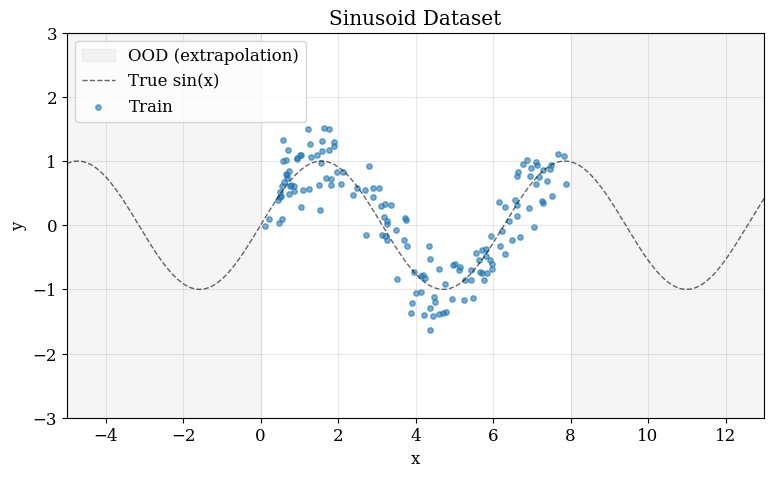

In [3]:
# Dataset visualization
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=15, alpha=0.6, label="Train")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Sinusoid Dataset")
ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_dataset.png"), dpi=150, bbox_inches="tight")
plt.show()

In [4]:
def build_laplace_variant(spec):
    base = get_model()
    base.load_state_dict(map_model.state_dict())
    return Laplace(base, "regression", subset_of_weights=spec["subset"], hessian_structure=spec["hessian"])


def fit_or_load_variant(spec):
    vname = spec["variant_name"]
    la_ckpt = str(ROOT / "results" / "checkpoints" / "sinusoid_laplace_1seed" / f"sinusoid_laplace_{vname}_seed{SEED}.pt")

    if checkpoint_exists(la_ckpt):
        payload = load_checkpoint(la_ckpt)
        if isinstance(payload, dict) and payload.get("la") is not None:
            la = payload["la"]
            metrics = payload.get("metrics", {})
            metrics["Sigma_Noise"] = float(la.sigma_noise.item())
            metrics["Prior_Precision"] = float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
            return la, metrics, True
        if isinstance(payload, dict) and payload.get("la_state_dict") is not None:
            la = build_laplace_variant(spec)
            la.fit(train_loader)
            la.load_state_dict(payload["la_state_dict"])
            metrics = payload.get("metrics", {})
            metrics["Sigma_Noise"] = float(la.sigma_noise.item())
            metrics["Prior_Precision"] = float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
            return la, metrics, True

    la = build_laplace_variant(spec)

    fit_start = time.time()
    la.fit(train_loader)
    metrics = {
        "Hessian_Structure": spec["hessian"],
        "Subset_Of_Weights": spec["subset"],
        "Tune_Method": spec["tune"],
        "Fit_Time (s)": time.time() - fit_start,
    }

    tune_start = time.time()
    if spec["tune"] == "adam_loop":
        # Joint optimisation of prior precision and sigma_noise via marginal likelihood,
        # matching the reference laplace-torch example and povertymap notebook.
        log_prior = torch.ones(1, requires_grad=True)
        log_sigma = torch.ones(1, requires_grad=True)
        hyper_optimizer = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)
        for _ in range(1000):
            hyper_optimizer.zero_grad()
            neg_marglik = -la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())
            neg_marglik.backward()
            hyper_optimizer.step()
        la.prior_precision = log_prior.exp().detach()
        la.sigma_noise = log_sigma.exp().detach()
    else:
        la.sigma_noise = torch.tensor(map_resid_std)
        if spec["tune"] == "marglik":
            la.optimize_prior_precision(method="marglik")
        else:
            la.optimize_prior_precision(method="gridsearch", val_loader=val_loader)
    metrics["Tune_Time (s)"] = time.time() - tune_start
    metrics["Prior_Precision"] = float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
    metrics["Sigma_Noise"] = float(la.sigma_noise.item())

    save_checkpoint({"la": la, "la_state_dict": la.state_dict(), "metrics": metrics}, la_ckpt)
    return la, metrics, False


# Variant grid: (diag/kron/full, all weights) + (full/kron, last layer) x tuning = 10 variants
variant_specs = []
for subset, hessians in [("all", ["diag", "kron", "full"]), ("last_layer", ["full", "kron"])]:
    scope = "all" if subset == "all" else "last layer"
    for hessian in hessians:
        for tune in ["marglik", "gridsearch"]:
            variant_specs.append({
                "variant_name": f"{hessian}_{subset}_{tune}",
                "hessian": hessian,
                "subset": subset,
                "tune": tune,
                "plot_title": f"{hessian.capitalize()} / {scope} / {tune}",
            })

# Adam loop variants: kron only, joint prior precision + sigma_noise optimisation
for subset in ["all", "last_layer"]:
    scope = "all" if subset == "all" else "last layer"
    variant_specs.append({
        "variant_name": f"kron_{subset}_adam_loop",
        "hessian": "kron",
        "subset": subset,
        "tune": "adam_loop",
        "plot_title": f"Kron / {scope} / adam loop",
    })

variant_results = {}
print(f"Configured {len(variant_specs)} Laplace regression variants.")


Configured 12 Laplace regression variants.


In [5]:
# Run all variants -> build variant_eval_df
variant_eval_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    la, v_metrics, from_cache = fit_or_load_variant(spec)
    print(f"  {'Loaded' if from_cache else 'Fitted'}: {vname}")
    sigma = v_metrics["Sigma_Noise"]
    f_mu, epi_std = la_predict(la, X_test)                     # grid (for figures)
    mu_id, epi_id = la_predict(la, X_test_id)                  # held-out ID test (for scored metrics)
    total_id = np.sqrt(epi_id ** 2 + sigma ** 2)
    v_metrics.update(regression_uncertainty_stats(epi_id, sigma))
    v_metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    variant_results[vname] = {"la": la, "f_mu": f_mu, "epi_std": epi_std, "sigma": sigma, "metrics": v_metrics}
    variant_eval_rows.append(v_metrics)

variant_eval_df = pd.DataFrame(variant_eval_rows, index=[s["plot_title"] for s in variant_specs])
variant_eval_df.index.name = "Variant"
print(f"\nEvaluated {len(variant_eval_rows)} variants.")

  Fitted: diag_all_marglik
  Fitted: diag_all_gridsearch
  Fitted: kron_all_marglik
  Fitted: kron_all_gridsearch
  Fitted: full_all_marglik
  Fitted: full_all_gridsearch
  Fitted: full_last_layer_marglik
  Fitted: full_last_layer_gridsearch
  Fitted: kron_last_layer_marglik
  Fitted: kron_last_layer_gridsearch


/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/laplace/utils/matrix.py:373: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  [pow(scalar, 1 / len(ls)) * eigval for eigval in ls]


  Fitted: kron_all_adam_loop
  Fitted: kron_last_layer_adam_loop

Evaluated 12 variants.


In [6]:
# Sanity check: marginal and joint predictive distributions must be consistent.
# Mirrors the assertion in the reference laplace-torch example.
_la = variant_results["full_all_marglik"]["la"]
_f_mu,       _f_var = _la(X_test)
_f_mu_joint, _f_cov = _la(X_test, joint=True)
assert torch.allclose(_f_mu.flatten(), _f_mu_joint), "Marginal and joint means must agree"
assert torch.allclose(_f_var.flatten(), _f_cov.diag()), "Marginal variances must equal joint covariance diagonal"
print("Joint prediction consistency check passed (full / all / marglik).")
print(f"  max mean diff: {(_f_mu.flatten() - _f_mu_joint).abs().max().item():.2e}"
      f"  |  max var diff: {(_f_var.flatten() - _f_cov.diag()).abs().max().item():.2e}")

Joint prediction consistency check passed (full / all / marglik).
  max mean diff: 0.00e+00  |  max var diff: 7.63e-06


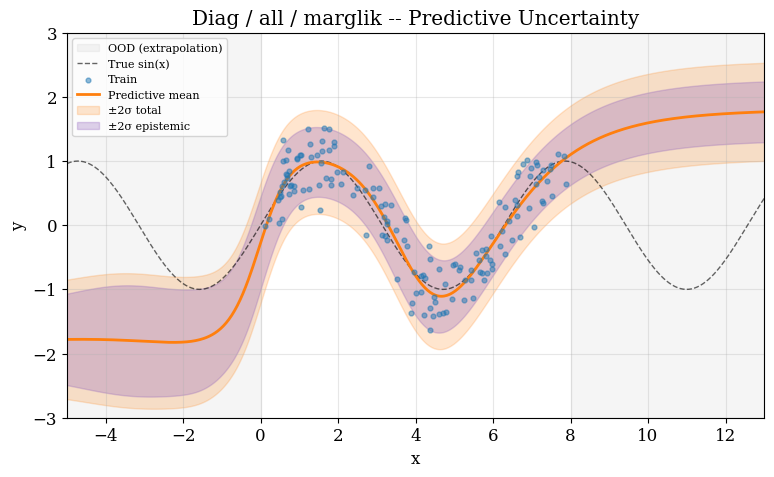

  Saved figure for: diag_all_marglik


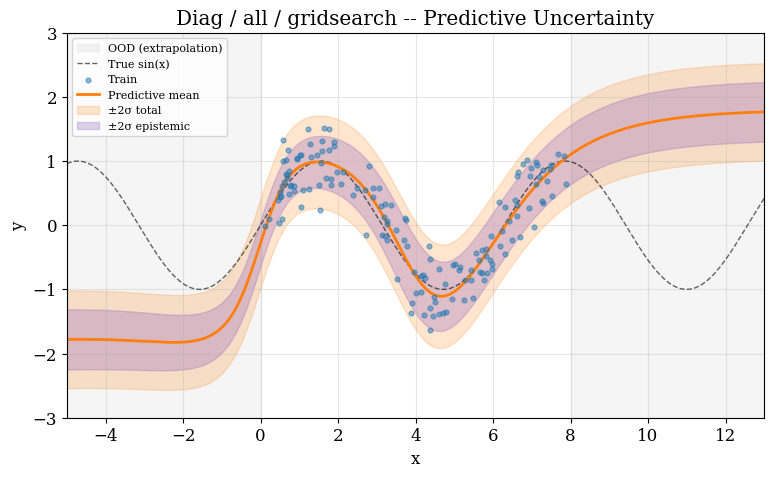

  Saved figure for: diag_all_gridsearch


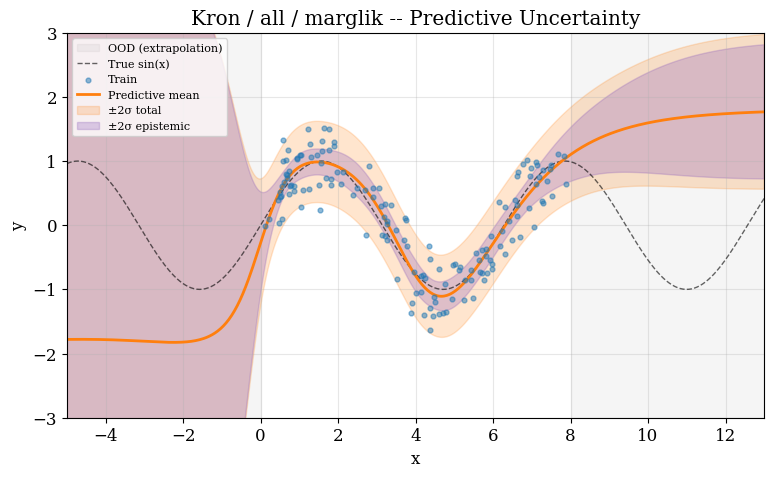

  Saved figure for: kron_all_marglik


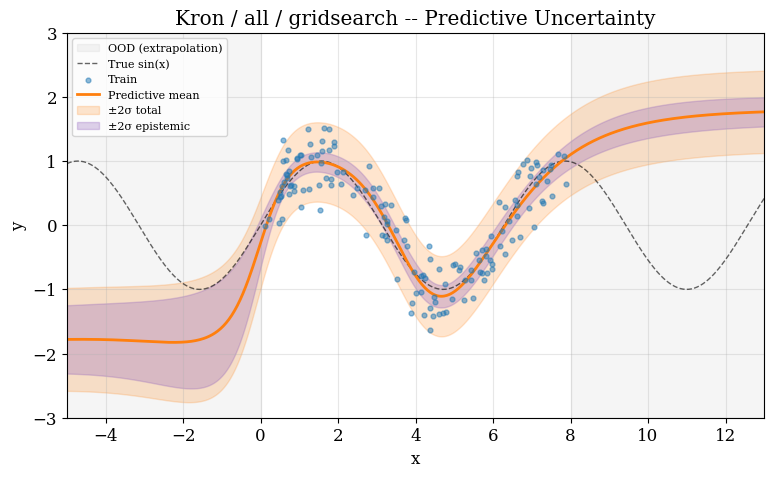

  Saved figure for: kron_all_gridsearch


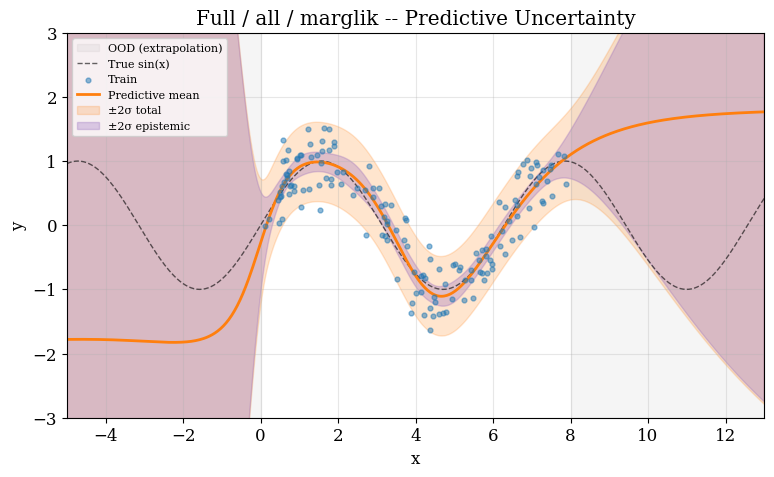

  Saved figure for: full_all_marglik


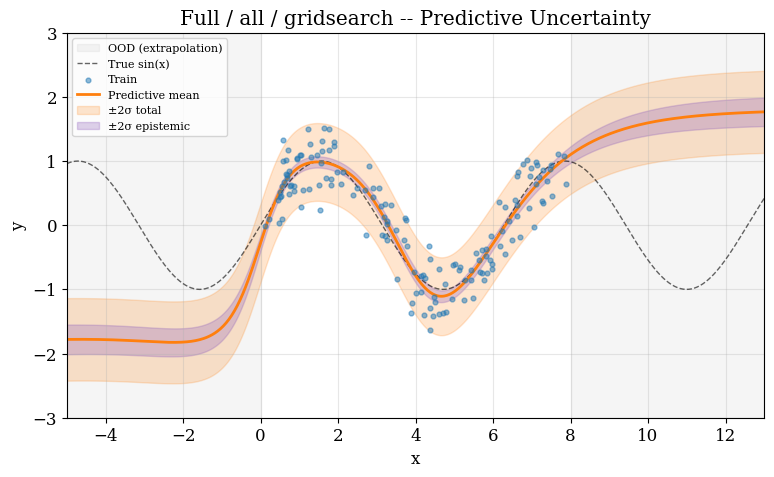

  Saved figure for: full_all_gridsearch


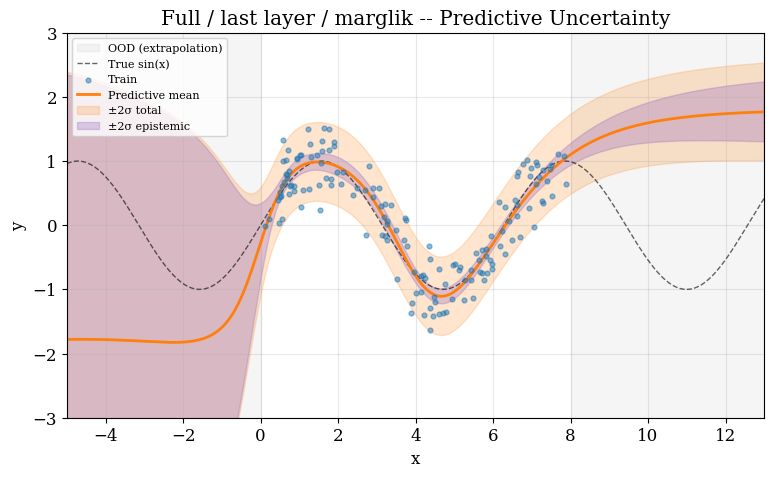

  Saved figure for: full_last_layer_marglik


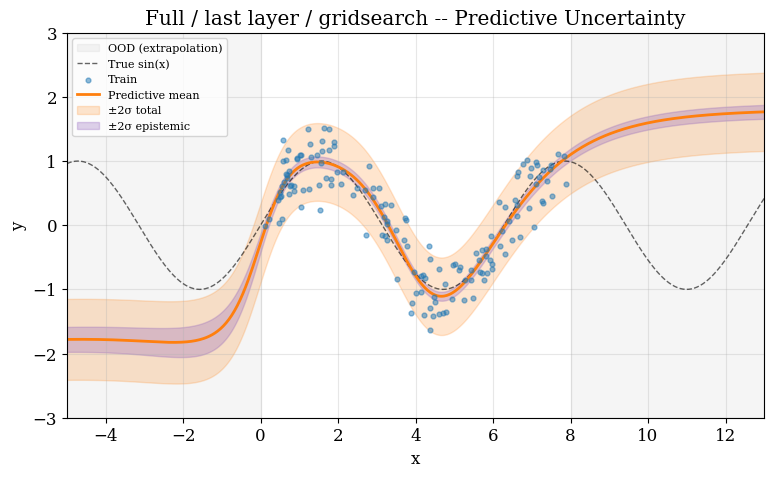

  Saved figure for: full_last_layer_gridsearch


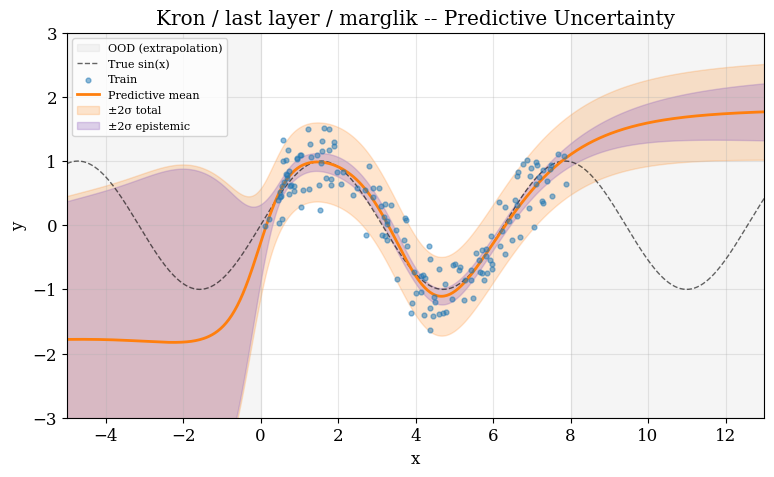

  Saved figure for: kron_last_layer_marglik


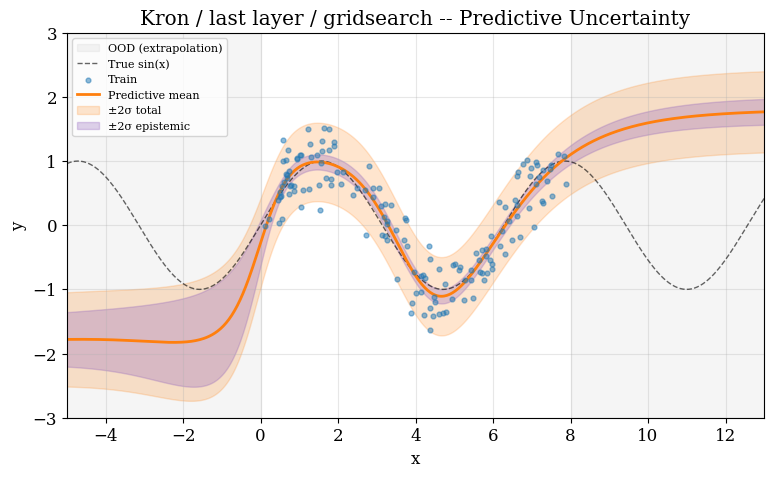

  Saved figure for: kron_last_layer_gridsearch


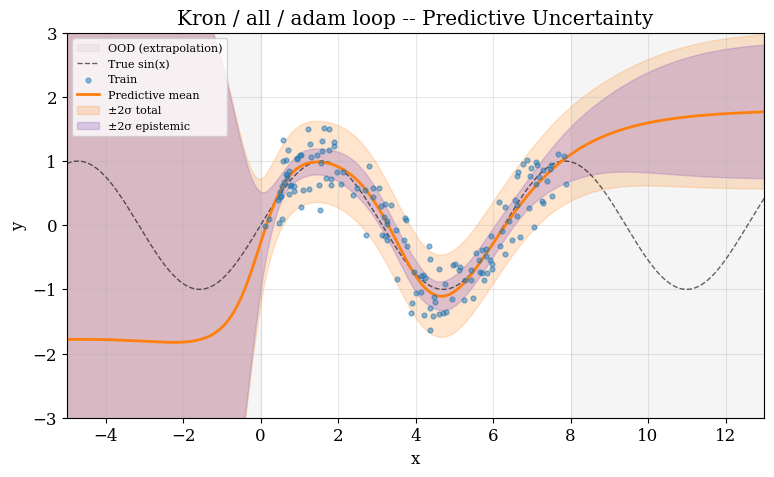

  Saved figure for: kron_all_adam_loop


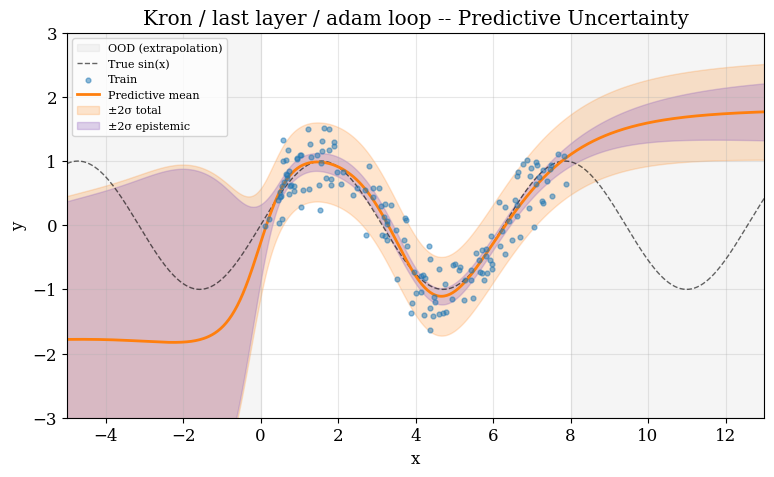

  Saved figure for: kron_last_layer_adam_loop

Done: 12 figures written to ../figures


In [7]:
# Per-variant regression figures (mean + epistemic/total bands; OOD region shaded)
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    res = variant_results[vname]
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, res["f_mu"], res["epi_std"], sigma_noise, f"{title} -- Predictive Uncertainty", ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_prediction.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved figure for: {vname}")
print(f"\nDone: {len(variant_specs)} figures written to {FIGURES_DIR}")

In [8]:
# Final metrics table (uncertainty stats)
variant_table = variant_eval_df.copy()
variant_table.index.name = "Model Type"
preferred_cols = [
    "Hessian_Structure", "Subset_Of_Weights", "Tune_Method",
    "Fit_Time (s)", "Tune_Time (s)", "Prior_Precision", "Sigma_Noise",
    "RMSE", "MAE", "NLL", "Calibration_MAE", "Calibration_MSE", "Calibration_Corr", "Max_Calibration_Gap",
    "Coverage_68", "Coverage_95",
    "Mean_Epistemic_Std", "Mean_Aleatoric_Std", "Mean_Total_Std",
]
existing = [c for c in preferred_cols if c in variant_table.columns]
variant_table = variant_table[existing + [c for c in variant_table.columns if c not in existing]]

disp = variant_table.copy()
for c in disp.columns:
    if pd.api.types.is_float_dtype(disp[c]):
        disp[c] = disp[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
print("Sinusoid Laplace -- Variant-Level Uncertainty Benchmarks")
display(disp)

os.makedirs("results/metrics", exist_ok=True)
variant_table.to_csv("results/metrics/sinusoid_laplace_variant_metrics.csv")
print("\nSaved metrics to results/metrics/sinusoid_laplace_variant_metrics.csv")

Sinusoid Laplace -- Variant-Level Uncertainty Benchmarks


,Hessian_Structure,Subset_Of_Weights,Tune_Method,Fit_Time (s),Tune_Time (s),Prior_Precision,Sigma_Noise,RMSE,MAE,NLL,Calibration_MAE,Calibration_MSE,Calibration_Corr,Max_Calibration_Gap,Coverage_68,Coverage_95,Mean_Epistemic_Std,Mean_Aleatoric_Std,Mean_Total_Std
Model Type,,,,,,,,,,,,,,,,,,,
Diag / all / marglik,diag,all,marglik,0.2642,0.0255,1.0367,0.3239,0.3006,0.2376,0.3159,0.1174,0.0158,0.9885,0.1809,0.8520,0.9920,0.2754,0.3239,0.4257
Diag / all / gridsearch,diag,all,gridsearch,0.2873,14.5294,31.2572,0.3239,0.3006,0.2376,0.2872,0.1008,0.0115,0.9924,0.1536,0.8200,0.9880,0.2363,0.3239,0.4017
Kron / all / marglik,kron,all,marglik,0.5454,0.0747,0.2059,0.3239,0.3006,0.2376,0.2341,0.0568,0.0037,0.9975,0.0942,0.7720,0.9720,0.1264,0.3239,0.3493
Kron / all / gridsearch,kron,all,gridsearch,0.5284,18.8713,31.2572,0.3239,0.3006,0.2376,0.2279,0.0442,0.0022,0.9987,0.0702,0.7600,0.9680,0.0926,0.3239,0.3372
Full / all / marglik,full,all,marglik,8.3887,16.7100,0.0887,0.3239,0.3006,0.2376,0.2285,0.0454,0.0023,0.9985,0.0742,0.7640,0.9680,0.0884,0.3239,0.3376
Full / all / gridsearch,full,all,gridsearch,9.4951,27.2181,1555.6761,0.3239,0.3006,0.2376,0.2236,0.0354,0.0014,0.9990,0.0662,0.7440,0.9680,0.0472,0.3239,0.3273
Full / last layer / marglik,full,last_layer,marglik,0.1318,5.1090,0.7995,0.3239,0.3006,0.2376,0.2251,0.0408,0.0019,0.9987,0.0702,0.7480,0.9680,0.0680,0.3239,0.3323
Full / last layer / gridsearch,full,last_layer,gridsearch,0.3182,11.9160,613.5907,0.3239,0.3006,0.2376,0.2232,0.0348,0.0014,0.9990,0.0662,0.7400,0.9680,0.0413,0.3239,0.3266
Kron / last layer / marglik,kron,last_layer,marglik,0.2337,0.0661,0.9240,0.3239,0.3006,0.2376,0.2256,0.0410,0.0019,0.9987,0.0702,0.7480,0.9680,0.0730,0.3239,0.3332



Saved metrics to results/metrics/sinusoid_laplace_variant_metrics.csv


## In-Distribution vs OOD (extrapolation) Test

The training data lives on `x ∈ [0, 8]`; everything outside is out-of-distribution. A well-behaved
Bayesian regressor should show higher epistemic uncertainty in the extrapolation region than
inside the data, its "I haven't seen data here" signal. We compare mean epistemic std on the grid
points inside vs outside the training range for every variant.

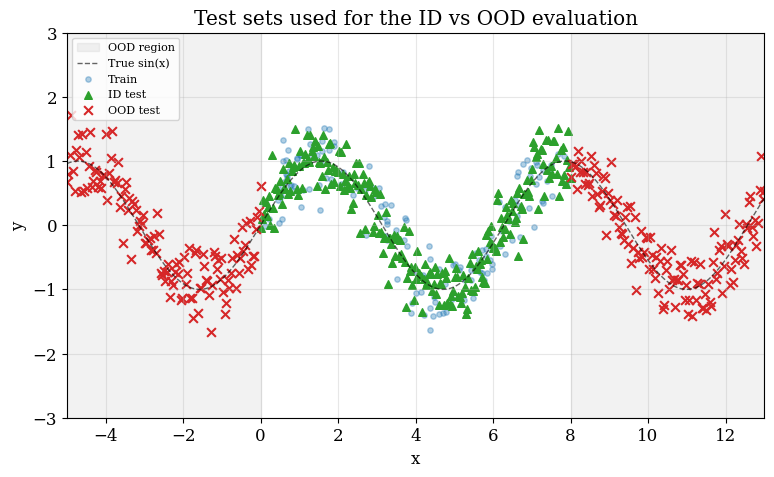

In [9]:
# What is given to test OOD: train data + held-out ID test + OOD test points
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD region")
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=15, alpha=0.35, label="Train")
ax.scatter(X_test_id.flatten().numpy(), y_test_id_np, c="tab:green", marker="^", s=30, label="ID test")
ax.scatter(X_test_ood.flatten().numpy(), y_test_ood_np, c="tab:red", marker="x", s=40, label="OOD test")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Test sets used for the ID vs OOD evaluation")
ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_ood_testsets.png"), dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ID vs OOD scored metrics per variant (held-out test sets with targets)
ood_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    la = variant_results[vname]["la"]; sigma = variant_results[vname]["sigma"]
    mu_id,  epi_id  = la_predict(la, X_test_id)
    mu_ood, epi_ood = la_predict(la, X_test_ood)
    m_id  = regression_metrics(y_test_id_np,  mu_id,  np.sqrt(epi_id  ** 2 + sigma ** 2))
    m_ood = regression_metrics(y_test_ood_np, mu_ood, np.sqrt(epi_ood ** 2 + sigma ** 2))
    ood_rows.append({
        "ID NLL": m_id["NLL"],                "OOD NLL": m_ood["NLL"],
        "ID RMSE": m_id["RMSE"],              "OOD RMSE": m_ood["RMSE"],
        "ID Coverage_95": m_id["Coverage_95"], "OOD Coverage_95": m_ood["Coverage_95"],
        "ID Epistemic": float(epi_id.mean()),  "OOD Epistemic": float(epi_ood.mean()),
        "Epistemic Ratio (OOD/ID)": float(epi_ood.mean() / epi_id.mean()) if epi_id.mean() > 0 else float("inf"),
    })
ood_df = pd.DataFrame(ood_rows, index=[s["plot_title"] for s in variant_specs])
ood_df.index.name = "Variant"
print("ID vs OOD: NLL/RMSE should be HIGHER and Coverage_95 should DROP on OOD; epistemic ratio > 1")
display(ood_df.round(4))

os.makedirs("results/metrics", exist_ok=True)
ood_df.to_csv("results/metrics/sinusoid_laplace_ood_metrics.csv")
print("\nSaved OOD metrics to results/metrics/sinusoid_laplace_ood_metrics.csv")

ID vs OOD: NLL/RMSE should be HIGHER and Coverage_95 should DROP on OOD; epistemic ratio > 1


,ID NLL,OOD NLL,ID RMSE,OOD RMSE,ID Coverage_95,OOD Coverage_95,ID Epistemic,OOD Epistemic,Epistemic Ratio (OOD/ID)
Variant,,,,,,,,,
Diag / all / marglik,0.3159,9.1435,0.3006,1.8737,0.992,0.248,0.2754,0.3172,1.1515
Diag / all / gridsearch,0.2872,11.1273,0.3006,1.8737,0.988,0.188,0.2363,0.2225,0.9415
Kron / all / marglik,0.2341,4.3784,0.3006,1.8737,0.972,0.584,0.1264,1.4095,11.1514
Kron / all / gridsearch,0.2279,12.3279,0.3006,1.8737,0.968,0.224,0.0926,0.2160,2.3321
Full / all / marglik,0.2285,2.3280,0.3006,1.8737,0.968,0.932,0.0884,3.0945,35.0128
Full / all / gridsearch,0.2236,14.9283,0.3006,1.8737,0.968,0.164,0.0472,0.1007,2.1319
Full / last layer / marglik,0.2251,7.8983,0.3006,1.8737,0.968,0.576,0.0680,0.8836,12.9963
Full / last layer / gridsearch,0.2232,15.6448,0.3006,1.8737,0.968,0.160,0.0413,0.0795,1.9232
Kron / last layer / marglik,0.2256,8.1830,0.3006,1.8737,0.968,0.444,0.0730,0.6466,8.8584



Saved OOD metrics to results/metrics/sinusoid_laplace_ood_metrics.csv


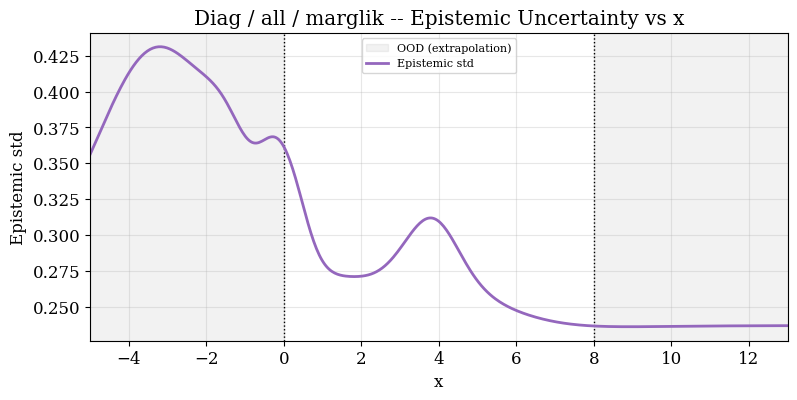

  Saved OOD epistemic figure for: diag_all_marglik


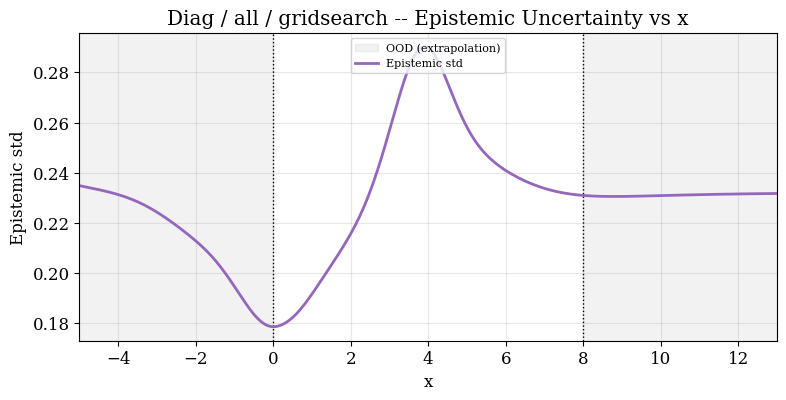

  Saved OOD epistemic figure for: diag_all_gridsearch


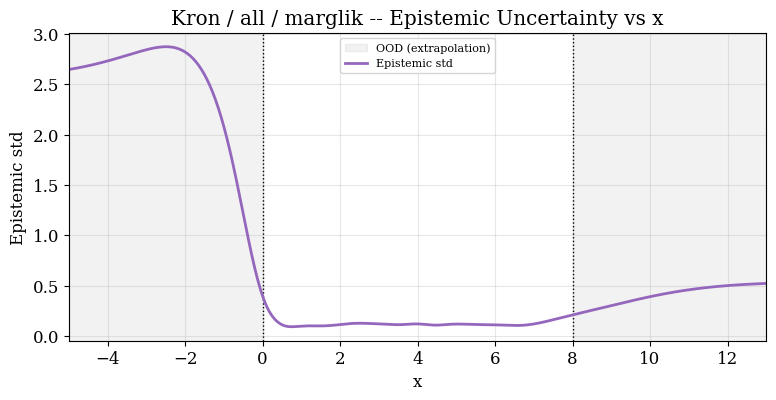

  Saved OOD epistemic figure for: kron_all_marglik


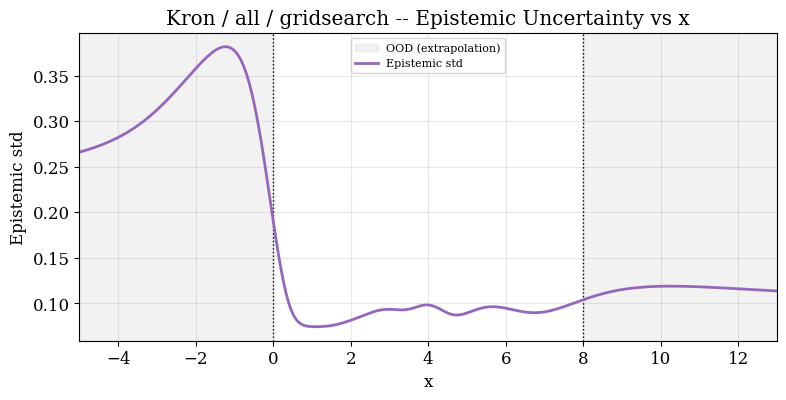

  Saved OOD epistemic figure for: kron_all_gridsearch


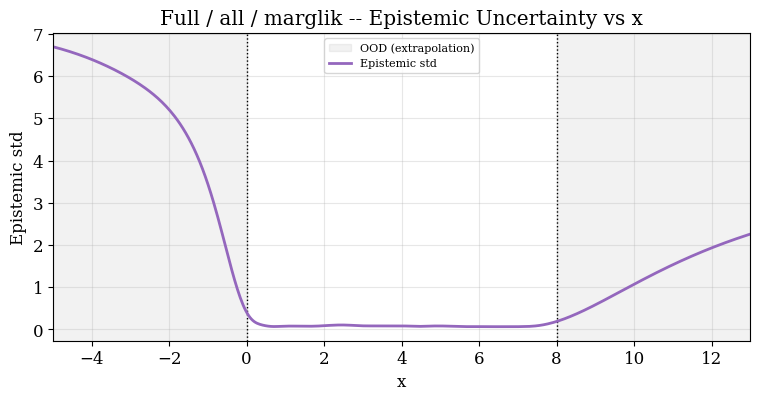

  Saved OOD epistemic figure for: full_all_marglik


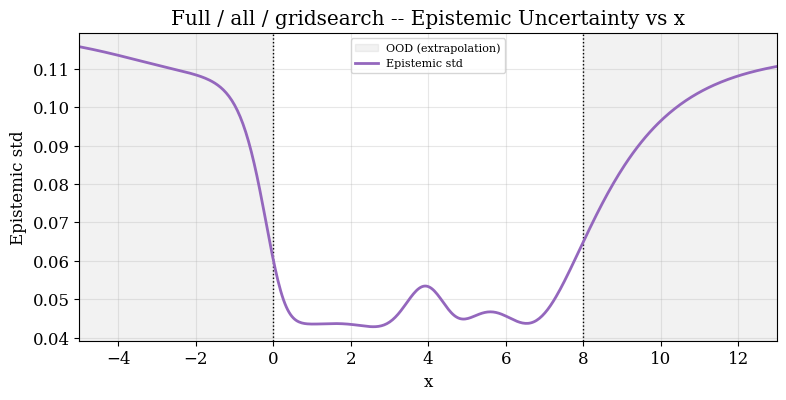

  Saved OOD epistemic figure for: full_all_gridsearch


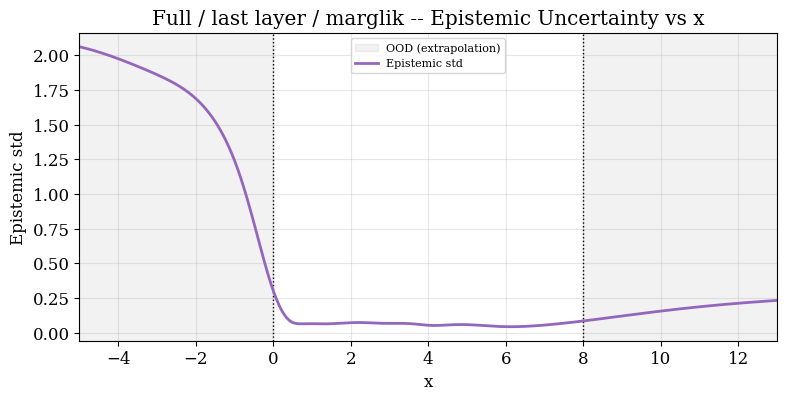

  Saved OOD epistemic figure for: full_last_layer_marglik


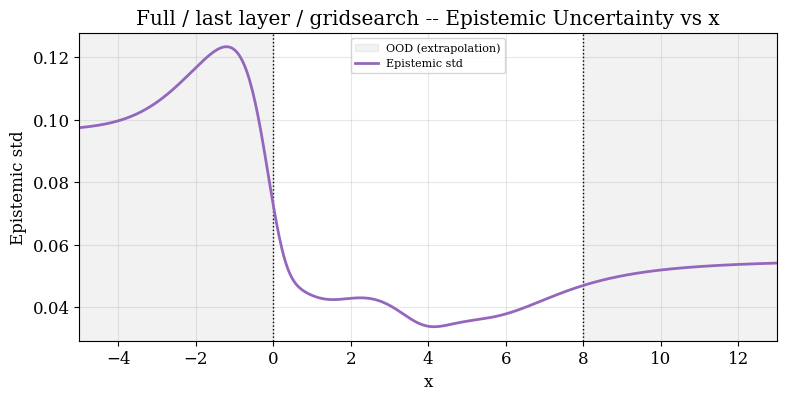

  Saved OOD epistemic figure for: full_last_layer_gridsearch


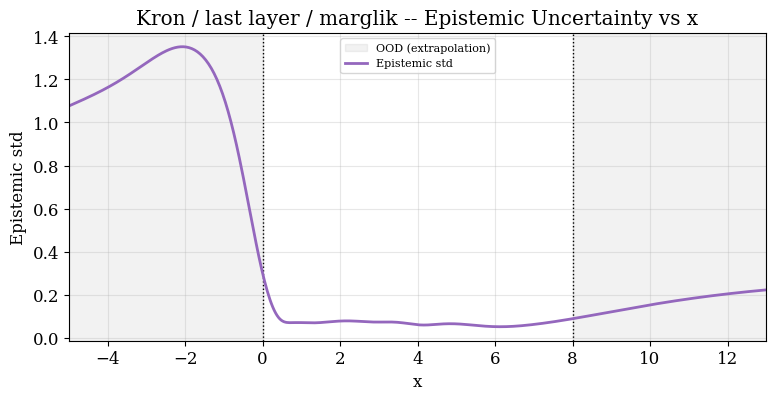

  Saved OOD epistemic figure for: kron_last_layer_marglik


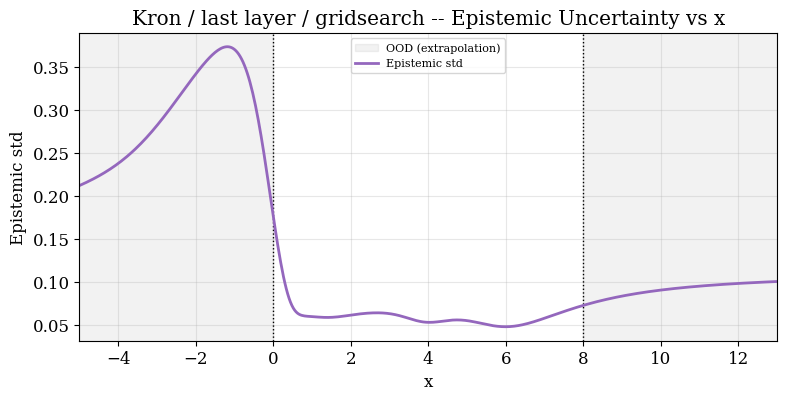

  Saved OOD epistemic figure for: kron_last_layer_gridsearch


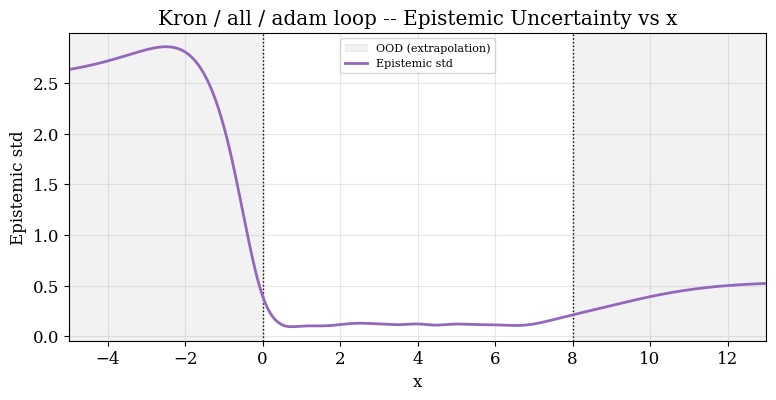

  Saved OOD epistemic figure for: kron_all_adam_loop


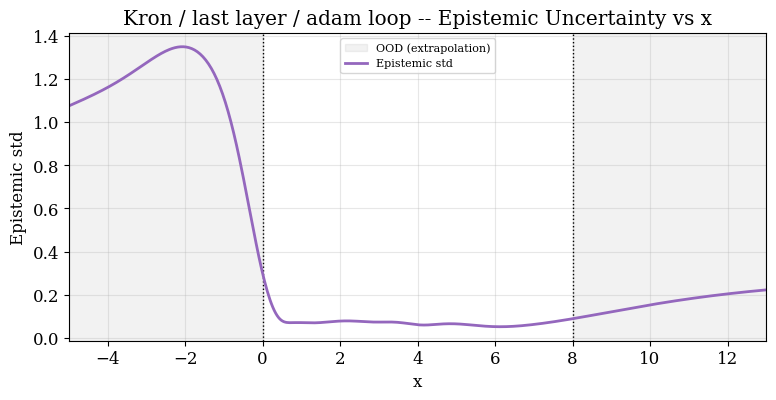

  Saved OOD epistemic figure for: kron_last_layer_adam_loop

Done: 12 OOD epistemic figures written to ../figures


In [11]:
# Per-variant OOD visualization: epistemic std across x (ID region clear, OOD shaded)
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    epi = variant_results[vname]["epi_std"]
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, epi, color="tab:purple", lw=2, label="Epistemic std")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} -- Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_ood_epistemic.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved OOD epistemic figure for: {vname}")
print(f"\nDone: {len(variant_specs)} OOD epistemic figures written to {FIGURES_DIR}")

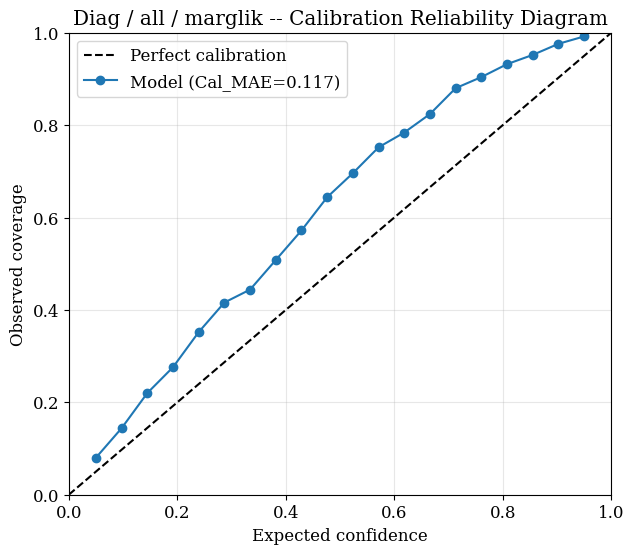

  Saved calibration figure for: diag_all_marglik


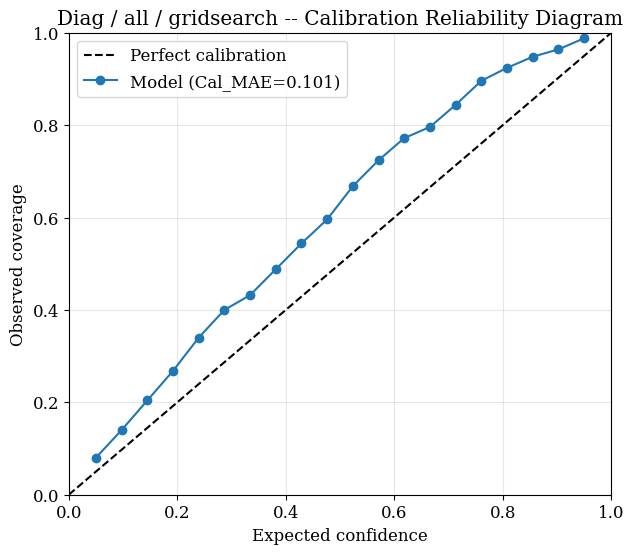

  Saved calibration figure for: diag_all_gridsearch


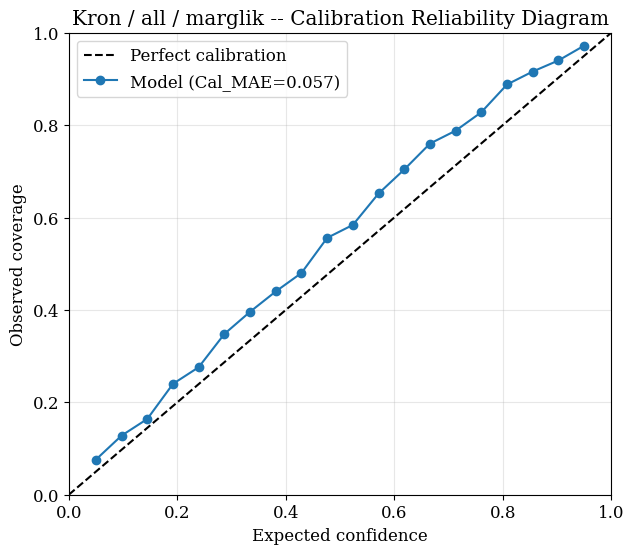

  Saved calibration figure for: kron_all_marglik


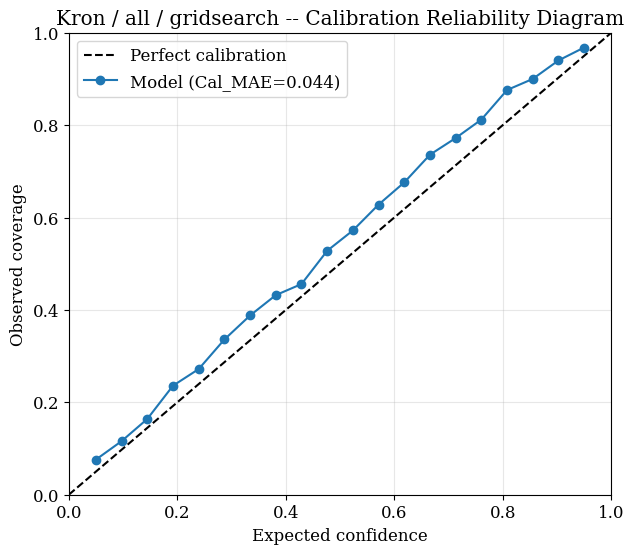

  Saved calibration figure for: kron_all_gridsearch


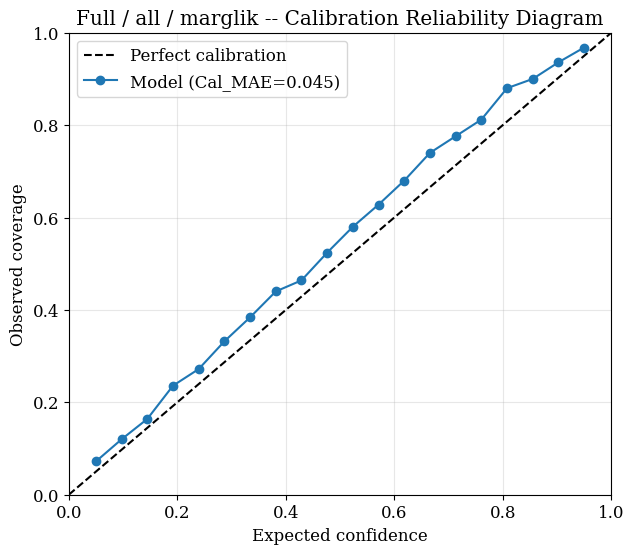

  Saved calibration figure for: full_all_marglik


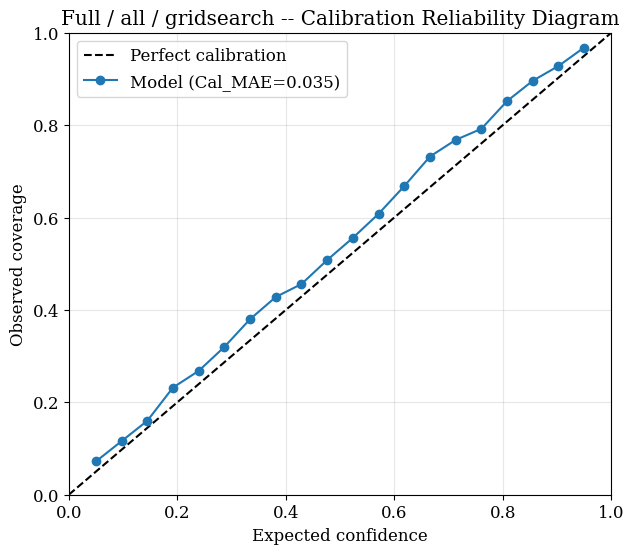

  Saved calibration figure for: full_all_gridsearch


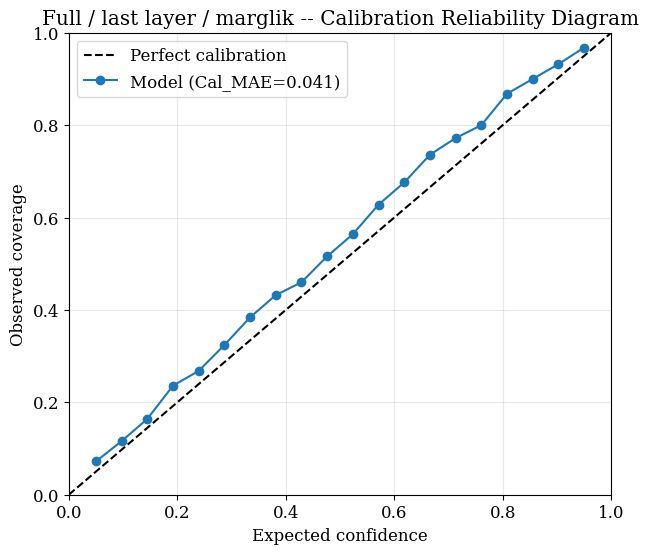

  Saved calibration figure for: full_last_layer_marglik


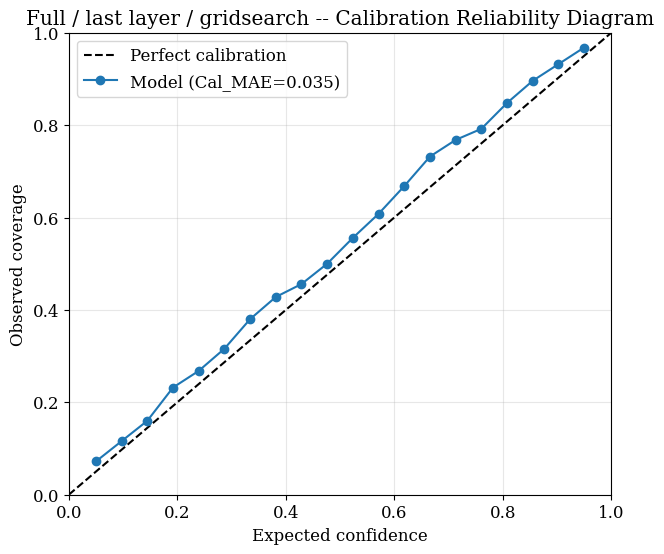

  Saved calibration figure for: full_last_layer_gridsearch


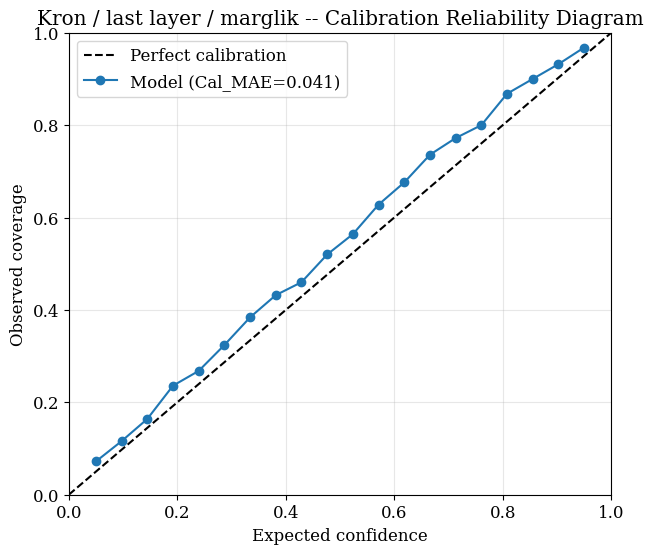

  Saved calibration figure for: kron_last_layer_marglik


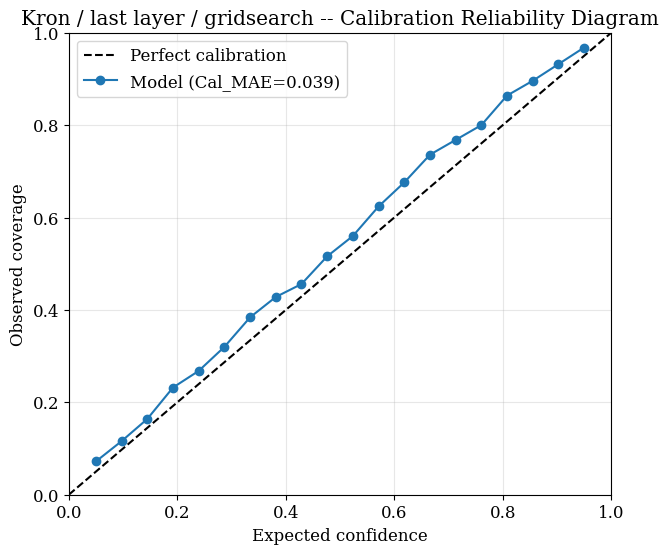

  Saved calibration figure for: kron_last_layer_gridsearch


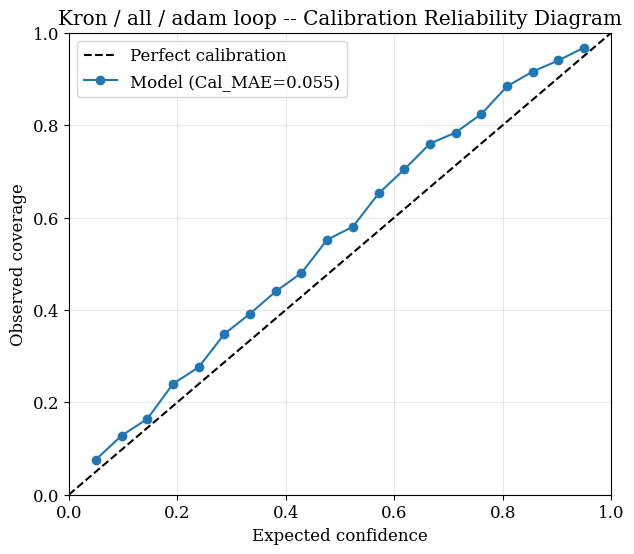

  Saved calibration figure for: kron_all_adam_loop


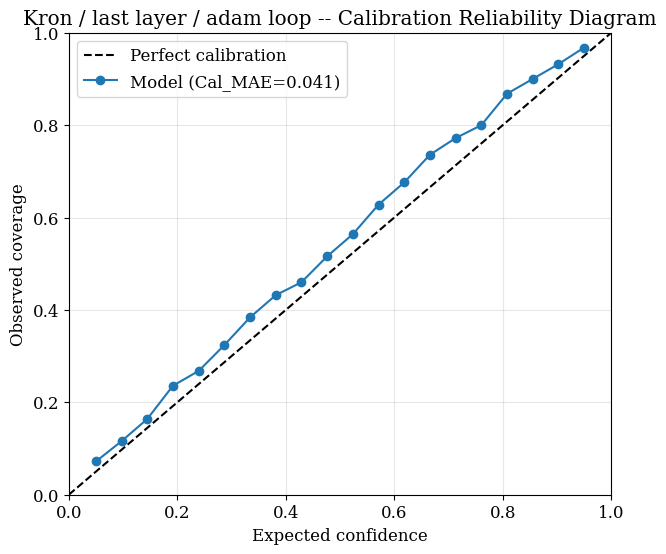

  Saved calibration figure for: kron_last_layer_adam_loop

Done: 12 calibration figures written to ../figures


In [12]:
# Per-variant calibration reliability diagrams (ID test set)
from scipy.stats import norm as _norm

conf_levels = np.linspace(0.05, 0.95, 20)

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    la = variant_results[vname]["la"]
    sigma = variant_results[vname]["sigma"]
    mu_id, epi_id = la_predict(la, X_test_id)
    total_id = np.sqrt(epi_id ** 2 + sigma ** 2)
    resid = y_test_id_np - mu_id
    z_abs = np.abs(resid / np.clip(total_id, 1e-12, None))
    observed = np.array([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
    cal_mae = float(np.mean(np.abs(observed - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, observed, "o-", label=f"Model (Cal_MAE={cal_mae:.3f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{title} -- Calibration Reliability Diagram")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_calibration.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved calibration figure for: {vname}")
print(f"\nDone: {len(variant_specs)} calibration figures written to {FIGURES_DIR}")
